In [ ]:
!pip install timm scikit-learn seaborn


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms

import timm

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tqdm import tqdm
import pandas as pd


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install timm


In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.calibration import calibration_curve

import timm
import matplotlib.pyplot as plt


In [ ]:
train_dir = "/content/drive/MyDrive/NDC/train"
test_dir = "/content/drive/MyDrive/NDC/test"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_epochs = 25
batch_size = 32
num_classes = 3


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])


In [ ]:
full_dataset = datasets.ImageFolder(train_dir, transform=transform)

class_names = full_dataset.classes

targets = full_dataset.targets


In [ ]:
class CBAM(nn.Module):

    def __init__(self, channels, reduction=16):

        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Linear(channels, channels//reduction),
            nn.ReLU(),
            nn.Linear(channels//reduction, channels)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        b,c,_,_ = x.size()

        avg = self.fc(self.avg_pool(x).view(b,c))
        max = self.fc(self.max_pool(x).view(b,c))

        scale = self.sigmoid(avg+max).view(b,c,1,1)

        return x*scale


In [ ]:
class DermaNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.backbone = timm.create_model("convnext_base", pretrained=True)

        in_features = self.backbone.head.fc.in_features

        self.backbone.head.fc = nn.Identity()

        self.cbam = CBAM(in_features)

        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self,x):

        features = self.backbone.forward_features(x)

        features = self.cbam(features)

        features = features.mean(dim=[2,3])

        out = self.classifier(features)

        return out


In [ ]:
def train_model(model, loader, optimizer, criterion):

    model.train()

    for images, labels in loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()


In [ ]:
def evaluate_model(model, loader):

    model.eval()

    y_true=[]
    y_pred=[]
    y_prob=[]

    with torch.no_grad():

        for images, labels in loader:

            images=images.to(device)

            outputs=model(images)

            probs=torch.softmax(outputs,dim=1)

            preds=torch.argmax(probs,dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    return np.array(y_true), np.array(y_pred), np.array(y_prob)


In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_folds=[]
y_pred_folds=[]
y_prob_folds=[]

for fold,(train_idx,val_idx) in enumerate(kf.split(np.zeros(len(targets)),targets)):

    print(f"Fold {fold+1}")

    train_subset=Subset(full_dataset,train_idx)
    val_subset=Subset(full_dataset,val_idx)

    train_loader=DataLoader(train_subset,batch_size=batch_size,shuffle=True)
    val_loader=DataLoader(val_subset,batch_size=batch_size,shuffle=False)

    model=DermaNet().to(device)

    optimizer=optim.Adam(model.parameters(),lr=0.0001)

    criterion=nn.CrossEntropyLoss()

    for epoch in range(num_epochs):

        train_model(model,train_loader,optimizer,criterion)

    y_true,y_pred,y_prob=evaluate_model(model,val_loader)

    y_true_folds.append(y_true)
    y_pred_folds.append(y_pred)
    y_prob_folds.append(y_prob)


Fold 1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

Fold 2
Fold 3
Fold 4
Fold 5


In [ ]:
precision_all=[]
recall_all=[]
f1_all=[]

for fold in range(5):

    precision_all.append(
        precision_score(y_true_folds[fold],y_pred_folds[fold],average=None)
    )

    recall_all.append(
        recall_score(y_true_folds[fold],y_pred_folds[fold],average=None)
    )

    f1_all.append(
        f1_score(y_true_folds[fold],y_pred_folds[fold],average=None)
    )

precision_all=np.array(precision_all)
recall_all=np.array(recall_all)
f1_all=np.array(f1_all)

format3=[]

for i,cls in enumerate(class_names):

    format3.append({

        "Class":cls,

        "Precision":f"{precision_all[:,i].mean():.3f} ± {precision_all[:,i].std():.3f}",

        "Recall":f"{recall_all[:,i].mean():.3f} ± {recall_all[:,i].std():.3f}",

        "F1-score":f"{f1_all[:,i].mean():.3f} ± {f1_all[:,i].std():.3f}"

    })

df_format3=pd.DataFrame(format3)

print(df_format3)

df_format3.to_csv("format3_table.csv",index=False)


           Class      Precision         Recall       F1-score
0        healthy  0.996 ± 0.008  0.992 ± 0.010  0.994 ± 0.008
1  onychomycosis  0.977 ± 0.007  0.974 ± 0.012  0.976 ± 0.006
2      psoriasis  0.954 ± 0.022  0.962 ± 0.011  0.958 ± 0.010


In [ ]:
def sens_spec(y_true,y_pred):

    cm=confusion_matrix(y_true,y_pred)

    sens=[]
    spec=[]

    for i in range(len(cm)):

        TP=cm[i,i]
        FN=cm[i,:].sum()-TP
        FP=cm[:,i].sum()-TP
        TN=cm.sum()-TP-FN-FP

        sens.append(TP/(TP+FN))
        spec.append(TN/(TN+FP))

    return np.array(sens),np.array(spec)

sens_all=[]
spec_all=[]

for fold in range(5):

    s,sp=sens_spec(y_true_folds[fold],y_pred_folds[fold])

    sens_all.append(s)
    spec_all.append(sp)

sens_all=np.array(sens_all)
spec_all=np.array(spec_all)

sens_table=[]

for i,cls in enumerate(class_names):

    sens_table.append({

        "Class":cls,

        "Sensitivity":f"{sens_all[:,i].mean():.3f} ± {sens_all[:,i].std():.3f}",

        "Specificity":f"{spec_all[:,i].mean():.3f} ± {spec_all[:,i].std():.3f}"

    })

df_sens=pd.DataFrame(sens_table)

print(df_sens)

df_sens.to_csv("sensitivity_specificity.csv",index=False)


           Class    Sensitivity    Specificity
0        healthy  0.992 ± 0.010  0.999 ± 0.002
1  onychomycosis  0.974 ± 0.012  0.978 ± 0.007
2      psoriasis  0.962 ± 0.011  0.981 ± 0.010


ECE: 0.02277236887825406 ± 0.007632518828701881
Brier: 0.015365382151460391 ± 0.004127662499936688


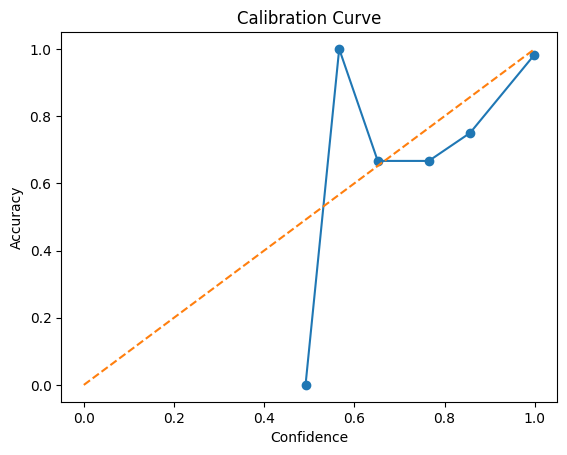

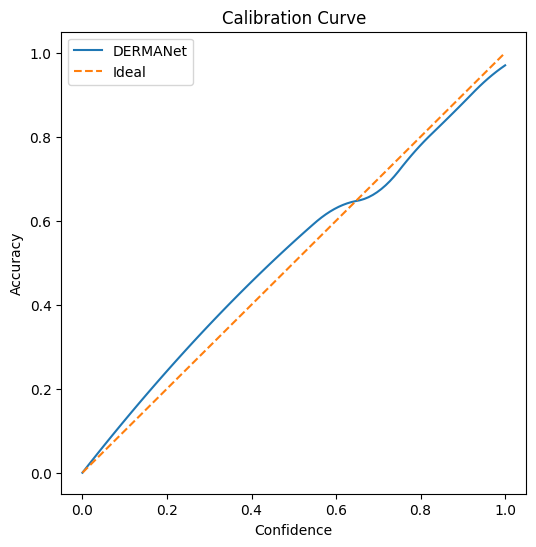